<a href="https://colab.research.google.com/" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open Colab"></a>

# CrystaLLM Tutorial
Paper link:https://www.nature.com/articles/s41467-024-54639-7



In [ ]:
#@title Helper functions and embedded images. Run once, then ignore. { display-mode: "form" }
import base64
import os
import re
import subprocess
import sys
from pathlib import Path

from IPython.display import Image, display

EMBEDDED_IMAGES = {'Prediction.png': '...', 'probs.png': '...', 'LLM_regressive_generation.png': 'UklGRlwmAABXRUJQVlA4WAoAAAAIAAAAagMAWQEAVlA4IHwlAACw4QCdASprA1oBPnU2l0kkoqKhInJa6JAOiWlu/+3n/+eAMYbAY8nIv/aDyYfB09NDzouAH0o/orej+YD+Lei76D/QA/7Po2+pv6AHTD/uBlQPkv/Afkl4af3z8pvP3xD+JfYn+zftV8e/7p4y+qP+V6Ifyf7Afe/7d+4n98+fX71/mvyE88flT/d+oL+Ufy7+4f2z9vP7dw0mt+YF6ofO/8P/bv3v/0Xp9f5P9p/bf3G+tn+9/tP7mfQB/J/6R/oP7z7U/8Tw9Pu/+1/aj4Af5V/Zf+N/iPyh+mr+l/8P+f/0/7s+3r9B/yv/Y/yv+q+Qn+W/1j/df4D/Pf/H/K////6fe97LP3d9lL9h//+SBn8GUvHU1vtFuD/TY9hSpnKYHSGJtYs3Vtn2YEIWhs37KeOGeTopJY5Wc0rWsb46QxM4XSqrgtvBxcYSEh4L8YDNuehns5NUg1Q6inxMPOUNxnDnIPxxk6EcVXRLgvBWTteMob/nLGiHRh3ZChuGKRABwkyQmqdigMGs6tLTA8WL5e6EihHh1Fd115hfA7ygLqrbjOzlCV5klsCCiGKa9LHiEfEE9ljz+U6ZbOlE4TqMYLQKMNa1k6PS30BTeQWBpKi0pdryeCTP+loBipC7+RvNIa+lSqDBg0eXDgblsPxwiCPEbdOzmiqsHRj3HKGt0jYHWUeKQS6hWuc3i9atjqNN4harLY7SYlHxY56XknWby7tERA+Jcd4kMOvZRYHF0SK/jr7LE2sWJcvbjE2tUlHu2syzFrM7APSOkMQU9rGJ3VjVNH2GlVmHMBhJTlMDpDEzYKNsTO1C9rGJoB9jE2rupNjkhGyGJrGJtXwRgdIYmcgM9d33gN5Y7VWr1/z2LPnN3pZyIwMw+smKOqjB02eiebMLAPdjkAMw+tQrBQ2Hb8c6j2U1TTODf6hAXXU7tqQSjtLrD7Dxyl3D0/UZiDaBXrDksIwM753lupJLV8GGF9sXdrGIKe1iz83BaSoy4D+dkADH+UJorddIW3JjCFUwb1iuHEY/SMrCYtj7uGdShsxXAqviQ5d5uE6tYn2/HPz4oJQ3F6CJTpUlq6qXaqyx1uDV2DKVMmSEPozPjB+tk2omh6U8RYoIBne01gw5Slbzoo9LtmYZRKjxaD47vWUHOd2NB0R1AC3AHR+CMDn58Tl1Ep6HePJz+S9+nuvwE7uYhzOmN1S7VWWOGVwVv4je8Cyotj7uGdY9wxsCib9egKGw7fjn58X/cn1tCLxsb2zl6AJSWLO3zzzzzTuUgj5z8PGHW8GBotrHOds78G25c2MQU9rFh/QssUOcUxPvvdeZhLoHOh0haX7st/gb+C9mowJTpj+pJRD7uGdwM3H+tG2sjeoCfqO//545+HjE0RC4jXExdQ3wMaAC2/fHSGJlQQhriYX/sfuZrRyhuMhwHKYHOJuL2ObJg3BGB0hiaAfYxNrFZxKhaF15B9lvVjfHSGJtGHjE2sW1NLY7VQAy1jfHR+CMDpDEzObvjT9nKG4TGPNUeP7j/OLTgfz+KhFFXhdQX4ImJipuh1LoGYgdeT2IcIuCSJvF5yUm1hJkiBx4DXzD0p8vl8BcBr5h6VCLgIvdO9MqVDQixIjeCBULCNdnTOptCLg3duE1s3FDLQofqFlgU0h6HARDt+B3+Ecx6oNtGq5UEM5vhW6Fm8wOZt1V9vOSYm1uj4Lcq9+fTmsJh7ftPsPyqquiAUKJf4TdVYIChGddZJYIr5iIGUxdMIBDnI7cKDIEvHGqBZ7w3hi0TC7M3Pr0Y3T/aR0iDD4JQQzbRt+gj70LgcIDgp6LvQbUpmJzsMssUukBqx19wIIzI9mieiOVwM+tlzDleB3JzOIUcercKlLbuaIM8MnOdJTnLtU8dRntNZ1d2zaqmfn5ekIG8wMTRYQGM5ItGxi7sH+b4CRQ+8BBekLZk9PUQEqwAJiyZ2OmQrx5j6Cdq6lon6o4EJDghqfkxhShPCg1iiNTmlzXgBtxBbmbJLMhBusU7IAXb19jk+sfLWN9j42bV0AgvqU+wwMSZPYC5jg+HIt2fEjHcAJxK9glWestlg+IJiJqwuDL+z7tuEsKvc2qgTY/zzicacJfIZU/ULdf1dc6dVF0fDeGsKwksposuHrEbIO0IPjKS3qgAmPkktJUBoi2GeaF3LM1DuZUeA18wqez5Vs7lhx0yRK9JC2mtk2KrbLhVt1aFcoORTibiQFxLhhnSWxVrG96p4SlcwsIkL4/M/YqtWsb46QxNrFe0lHjFgeRLjOcjUaGHmQwpMYYmz9YLWw6Hv18dIYmVTqbxNQM7WN8dIYm1jE2sYmcnO/aha9AHet888whhUqf89Ecoa3yvuTKagDvW+eeeeYSO9G6lrG+OkMTaxibWMTbAq2O1VrWN8dIYm1jE2sYm1jE2sYcAAD+/1/QEgx1OVGIRGDQjdEuviJoqz314yEOSIGUFbjS4BYKPRjt7yUAKXqyuHfNwcFwz0kqTIcCZ/TrjIHb2gpjW67hRgKERS46fKXJlrA3ebzMEUci2jziUyZY4pwpRtfuh7bcUIWGyLRNAa3tBOChyUjRC8O73g2j9+j7KNUW6bzJmri0i62xid4tW4C2spK6Ml5mGacADuquDDcN6YGu9e2KEsBG7tVb9y+3l8x24kS/ghiBYY+hMeLQDcsa6kAhElJDLsOUMFoFzdgqlF+/F9nRK6XIzLEb3b4WUNZXWpgHhxz9S6lX3E2vmQoNgTxPzP4c/sKSUY/uAJbeoE+YDDT5/d7hD/9NPdB4GIr0ADOHL6Uecj1WMi1tl1zZI/KdrIUqNqaMKQMx+BF+UG/G0IFWo2g5CXI5NPQmvyTa97PZom0SjaVz6wM/XwWHuyMF18Z5yXDXGXOI3kP7xbq86qFujbw8OhlbADmvEffXHVcaiyLZ9KCOZmVKG+uQac9s6pIgnfRblxy7NH+eqap/5xD2w2jxXX+Qrg1RV6Kx+XJbrU4Zo7+xNsI7qI2X/+gE7w/UcQPkK/bqVBwi9eNQhlXlnZzOYNmiIHL4HQ1MnxY2XeqXmLDyudTPpif0JJYuptzHcsnQkJ3PxQTSJkH5BrJC5KZT7HdW2aDu8e8mYqk99IzX0GVajDwcjHRExZ9tKHKz2jzogTku4SkRwTT2KknwivexKXQmdhvFya7Q+gdQ3PvedF96s2eanM3cCCN62ckm9kfknaTHbK/MJHD3p9x//gqbeV0OfStvxV6mcR/cI+Qh09bIqznel4PNNja7EKdWFX3KF0oOdbFuUA4ODcnrGPFT1Q68KP/il+71kiUzFREz2iNxR+HJrWn9o+qDjII+3EVHsPt3dqOB+G61+S1SRQHc0KsRi5lIwGE81T8U2oM10XjAQb4fHQH/V7d2WjrIzFft1QdrrXl1aDLKnHspRxHpX/oLIilkAE/7gZxruP9jdH7olKDxA1a+NYNMXfTog4RMtO56DxKGyjEwlgziQ0C+5FhZ750lRK61ain5mpE48DMFXgzCxW63Nnf56BwMzUqMfwzfrB3IjZNZX55QX2YdcBZt1ArKRDbjfcJFVAha/6yRqq5Vz6TyLyYM9ZgvH+jvVX5KIxBCC9zZVRft43UTT+xj+b99YTfUo9jLwxxLgyAdRZYeH4Ubfd1a59CRMfCK/Lu4gObsFFKv/sPTkA7E7wfFtF+ufmJr+onsYukhtoyg68pqRpDyIl7CFhriSVzO3tgtvD/wowl40ob/kBEYImKbjL/GOtVUT/VbkDRheLaMu2lrWxvcjUvwVpft9DNtoKFwZPTA3qXAzbgp9rRHdwhE4ZYSWP0gkFhnDVaeNkEvxt/wrZQOSFX3KdrQ9v7UnKjrOLWo2XCNdJY+PETZuYRlHgSN9dgeComFFxdI8NWfzZ1unaujc9asCjxc61LS0fDB78yOUvlzY0fog5QD3N8gBX1aOfkBKU3uIbVwvcXwMkMhzSlXA5ldYpiNNl7RHLKQZFxp+XKdn6ukirjaYDzoFPrRGGyojCqVmnhOG0PH2y5UoUk8T3Tm/PE8XSfJGuOWOvyzcrMT/1jpGjay/cedTsFL5/nc6ANI7QIE9G+6Rc8ujTs3u1pLQNPQjcV0wOYPcFNMYum8hZXv3tJm4w6O06ojaEmtQOBC8EU6hrZvfLp2uoxztS5h3a2Dsq4IHp+IzQRtWDpO9pDKlvjVKpbQj8U+/9F1gwnmFUzxODZ4xaQKJWqRZiYQ73kgCVOodt03aVLfoU9RjAvCF7vdGGTvRsQ4pHDpois/w579d9wEIvt+4i5+xSqookeF60FL8A26wuxkh2FlrKCcuEPlwAzH/Z5PepEx2F1hj/wlg49Hf2w5aegMHT/POPsh/9cvzyOtu70CizTVttmXr+VOhCoaxal0J7xCZHBYMfVoeqcbAuFFikm2a2+3fZi9cy0+3UJZDYwuaupCKukKGe2NkSXD8fKqgsl0IOnOH4HN1pLHlgpuALUUb0DJ8TxB5raS+zCyGIy1M1KqNQvCBuzUkU054MysPwuaDDIeB4w0a6hNmDMdpSiJH2jhx+U1DN3cwaPEboUIyaWWWsHd8vHzg2lyzieuGmqwmx6fjE2KMSq6XzbwGvfhrOGxFXImYbDXYcL2JZFWTM1VIpf+6XiRlRj+zrPW+WF8MERFqLZKPA4BJ3p7yLN9yyGAJucTzP9eSQbiaVbwErtfG83szQ1WU00DPog+6RksQUubf3LksLGV6+SHhVNIkaAooKnvBoxgRZ9NyUJiD/tRloLs0pa3GCtkJJ/eQQwYFhVAAUxD5gCtwoYwfnF0r/Mp5S2e7OnNDj0tFhqPClpYn2+SViV2+mPkZePAraUepFn9X3wj9lZNow+/1jmT7eV/6JcytQPRgxX0CSHewKZFZn/k13Eg85ai9h8lxG7m3YNC12ILxKuSMIf2KW5ZGE8zdb7Q7yLgUrcJUJ54Qy4mW6bf8bXTG2b2jDZqAExz7915AOjzrKSzdLXjFoV1mX2Lo5BjeQmBMDFUEYUa2gc8WlQMuUbCC2kF1RnxWAiGwAABAAPmhhYyQdmIqqEUPX0JoEawsqyByR9mPqizaT1jbo/pROQh9zUg1+ugUuF5iiDOOEOu5laGbtL3n3oeLkWMTVUoGArG3sohpuCrJN+HGWuZlfeVpNeePeu4kbYz1BHlgskFQCmzZCnnVVkiWh+EGYg7IFlqNmEk6KR3FJWoRS+05jcfw0Ew+so228QHy8SheDIogUHS+f4F8Z/O/5LP7Oq0qKaCSvfDRu6JR2LMS0z16Lz5fEG+h638ELDrsPnuCcKQl8YnygX+Bw2sFxgPTpN7b+uJmboK0bp3RztPOVi5oi4k8oCe4CpOblScAU0uOPGfIOONpv8bmIBiy85mYHb+IK4xkBocSmQRBXjd2Toi7jVUQWBm9azprGukWAa78quhsNRJtBRyiGRmD73dkBfGHJv6z0+QPO3G2/a6TzM1W82BX/mYAL2/lQyFNFhu0xWud5g7KmEeaA/bUogL+iA32Ihe1nmSCgg2Tkp9osy4QjQRDRkmvDC8aZq2QTTeq8SDnn/7aEpo73crx7KtZbW0Grr5EWWMqX4TLntB2Paj8mhA+q6MdPVewZM08zGcF94b4aEKnreU23VfPsbg3cXA0oIGFpTNznk8km4r3rK97xPwqsoCtVbK601orPXzuYssBRTD+apOsGr+KevS4HCnJNo1hyLzl9TdhIsver0XncPBS3uiMiXrYw2cZMme/X0J1T6t5lXDirnW3LmZTgy/TH9Hvbu8EnWmA4ksursap1V5657EMgyfNE0Fbm1sd4mdDnaKzIbh/bi3WVCwjbsZilNkuViO7qgwk9STf2lW6YSVoNRaeI06p6BXv1ZebbOkZZ7FvCPB4P5aYP858J4ndFzeVFCvPc6wL0GnD1ZPEpb58ERW9mf7gSNmYK/APuezCimq2tYwk4MgENN9gL4v6B6/rkds9sz+0Dde6rYeleai2lFaURYPsq/arI19pBiWVdLUN8Z14vkR5tN0VCMqStMjzQxVKPWTwwUTUz+pVXsXTSvvpsxyEihbduza8nXSoHBBkOiWzHC0MLNROSVZxolU5ixmHy4GfAVddcvcpLf0TeSwa3g3eLVBywvQNCeTY1t/cVbi25JpyJTEsJROWm47uMh5iORMv83dWRLOYma4be6UiCB7K3nJNvWdbsLM/lBTGLJQYQDY7pbQa9h7RpOkHcEvd7CiY6bBqwkJN9yPMaIp8ek0d2L2y9oMLS4HEznNr0MGsCh9xazK/fCR+zyRmpmK9M2SsxXbigFDFTLYSESkkbpou8G7r8XYrHB8NhUd51j8RlcIiXqLooFfqECBG4+/eiJo1gM+sBaHH2VxnLjFNFVD3A1Wrzx7yXnvFZ5ueIgskYDQGL0WIEcP0CopEupb6QDrMWlybzRy252bXWilx0/Fm+KXrUV5wCIviXpH2aosM4MZ0OA7CPmy6dRlFljemUE1Qnp42JaIFPbReuoOGR4MlH4J4HYJAixm1vf0xlgazFYphGjsVMRZyEpXb0qZnnH4usFo0l4+V/lzwdu/bSAGmNM4DHAcccdasQeT6LUz8A/vYbLUGl8zJ9PVKIbL6Zoa5mIUoHleh3nEfNc5a9fDn29WAju4hMzY3+66HxMkup9P66FzI00NuZ42QVTWxMA4tAPuVz9RLtglV1AObQ0zeD9STKdw4Z4vQnpbrfwe/NyjRx1Pyiba1Pn8NrHF1/CLnGQyBwidFnOrby/mN5cuPptqelDObjDvXKNgZB7TH4rEEHX8Dgjp+SjsnwxZhOng0Ojm4ZEce3OV1Q6gPhWo93U+MwqJxRaAGiQVBU7qcElIdZ6NP4eoz158R/mlBMh+dR0N4bUdGlmJzf+i84K3V6WjuSbcEIQP0ARC9QABmme2OVHAKKZHTC9vCGWfD0BN4wFMKhDZcrJ393d0JW/RpdVu6c2wyt9VUKE0tK9+Xjh9XMH51VZ1Lw6grPJ7mAj89u4S8iB3CwSytzTn7AzRg1BoUpFEhcwnfctYx+ZmQMgD3C0aZPZ9h603DkSuQPvTbkgEp48LjvufWz4466wJRKXnV5VctgWcs36k5RN67WgJSm3AI0v1WS7vJw6/jkfA4mB1hgK7sMKdBrxljlAbtHmtNqWwACgd6mL65iDOZpZUd8M1lsOBjXrgAC6l4C7/iZHfXzNCDGo0hOCqvF8/lWAHxde4a/nptcE56GxFoHpEB7vJTBysLGg2YOERnUZUAxHRSaw/XNwblqYNfjSiS5ffPMfw2rLXcPmvBkvjTTz/wCcIKLNEjk9djyPGAVolfEYzdRj/697rzDfDIcoEL2epVY9jjDXMTSYe1zzVPu/FO9329ttF873pBSYS4AEnm6DplC2ybr/cXgPAoy/KusZGwjL2WizyYzf4wuYQuvWwGugGzjwUt4GWVWIryqgi61aXrJtOOu7hqIV+pB89Sw0ghhawL1iU+whgOAH1kAeau5ZV2wEvhA3XtmDsuysuI3tDIBXWyTXh9c9XkSKjZyPl2GVMuDfnu7D7aaSLTgFg8KWm0Vop8y3sEWsDTl57nKDsxWz2a71noDsY1Pr7ys/EVR7RPhQ6wDwr86232WVl099cgG+zlR2fCGHM07O4TCV2xDw/s1VKvwUd/XHBD+kw9JUPOGcKdf9BF8ZFKtLOlNamL9OgjB966WYSwBU+ogPp8UyTKtJKMGgGrbCG0q0iFg583GDOOGtzc6k6Pfe7+emEwCgC9Ds8BXpRVZPxzCXqnePmeg06B/uRahHfuIVEGxcwnSrwpflTjHNfQ5E7snnsP6hobgX+/3T9qM50HxkpNFtW2pER3nzivT3JsPlu2pvCZOp2Y21WTu5nYa2z0dG29tD893tPM0DJn5Np4XylzRj0zZCBpPCAU2b7EpfsST52qZJorUy164BJ+ZE3VzOW/vZsMUX9gEyva+FZlCzBjOXFmmRL2Bfe0rS7N9zpCjPdywf5U7AsSG11vComxyJh464qgBTZsJy++EGFIfdLh4Wi2fioQYJmdcUPGbVkKLe4vQSfkJ1F8VZ8wnqEHjwFHSOKYRuaar+ATCP5B1lqJJ3Dr5cJVmcckzM0HyqZ6NRno+2andLW/QAg5hBgvb7jltLn5xOhIl0KVHhw41XrDf/GXvPY71u8GlCqTKvJ7SHG8Hl+5qQyP9T0I8H6/+P1rBGR1YH0bksjqhUzlDCCBWQHIVoIUxsaRVadVP1HPexWdP0R9TcKDnbhe8tzB3v6qN82lxmKZu3kPPdiNhlYLSMTvINImOvClW2BrWk/bhITAempgIxr4YRUXh+CNomoUCsxWd+/+HI3P3+WISUva4jR+GrPaIpT2T+8F1GpUym/gBdBauFNhdcHs3LHyXs+k6+ErawjrcySBqXVQq7gKWKx5SrlC54umyRHOBC40v8/d8z2bt8DVbIvAlS6PmuDuBBxbhiwcavlWZtiUCc8Ze28fvyU+rzkjigz8mYfG6eg3L75sxcaHdMULqjuouwT+MqCoOpSFKWXCFWTQEOEGsm2BnQCmMUnMGhZ7IvUN5FUnKkOjxwUdOeb8xYYpH3p1xnNaAsp4FHfgOF8/DmGbh8tgAlXoqOqadCxy8AHOgx+yHf/GqI2JHmw0jBZ8f7WMuDQorki94tHkCuTWpaCPaiwi+8N9MfziDxSYgbclBAHWcbDQljotzNZEw27UOF0gwl6YehJJ4Yv/EBkSZyfGsukfbQsgZ712eOA/FcTcyvfU344wCCCb7PlIrSC4Kyy3Kl2C9J/AXnFhgE+Zv9TTVPVGsxnlwRFqTYARrqpDxWAw7kz1b/o+RVOnAftwP0Dz07qKjdmeuXriofxuhOQboPSEIIdT87BXLGqiU+rhOZsnsENI3IEyRJLvA0opNzAiFVvnh+dDXNGnyqf+ryXOofxap6PBmeZOf9Dp2EWY/fFoFU0GOH9t9/6CkvTSouhtZk4EE18DWlAfS9jqTfS++Ev5s8K+xWIVAYEaHG9VIfybuo48W/19F2j7R9Yy6pksZ7u80QspdCasd8Y2xlaoGMRYObhEHzj95cotwTLrIEO6wkwLHFEzEOllycvs+p3WgC4nR889g2qw0wMlAXgkKokSl8OCgwrp+kKcfUKIUnbtRYUwU/HpQ4Ddnrk3/THpCw9xcFSJVeTkv9kxLHMUs/w37an0MZDVaK3cjHWvoIK2EcJlAb4+UdA4YPmUrsxolK1l+KCnph9IKH+ffmpJ7k/K+f/5UAUWT89v+Pk88qf2OR2fTH1rQq5THP6Rv3ZzreTVMuItez5qWM6qTtWb2u6DVvh43RdF2/kFnMiIntki2cOooL1ldllOZZMAMoJf6tCiBkr/HEiv/6QG701GdvYWZylgxeJFFQlVOhAiRmw5zPemsJMbptxdOWZo3uST4xX9ELgYVF+NzxX2Nar0TOat2/CydXxK6JnsOLLaRcBqDZLXcm20KC74H4wjuczgIIncnyJQmSz45NdLUnSXss4trcSTc6kv6KfOBhCSzekRnrsHlrsR6FML1B9BAtvMUcgvAMhE0/J52Bci9ygm5ytmLYS8fMNDjXTti7N9ulzshtL9uqtkAL77LS7rKhalyBXo+XeJoy4z0z1Q70LMXR6QVXX+98bb71lrF1LM55oatZUdXHT9JCh14TruedLWYWqA9ENlcNo8E0XLrS22bMPOnYN/wD88kc6UBqnoG63xYDnnqbsWmHkwlhZJwmR/6Is+qtRBSye3aRalppAqt8Aq97xbWhFPnnMoxSZJNgMS79rjVg/Oc4E5/7IaCL87/x5UP+IlY9LC6KeDvKvMWIzDPjAzOXaDTVsTeJ/shX79Ujn3lLK1IG7Gx+jxfbWY49P2QQsPe2Xo/nMWkEM59V2TXakpNbQBwKJ3pTxdEreFP0RUqMGQkW2xNIdBx8M3VbK6FUCbZYTUiyFVikDFY+u7htPAWM0PJJJZ5x5V5fKnQ6BWYv+BO4mcmR26jqookmzuyXvRyz3X898WLd9ZDzQC9yfoq0VJSsRqXFVdkpT1WIpjIgfsw9nj5xOb/KMKi+a6mal2WZtt6OnyGcc/lirdGeR2Y+RrdudyJ8q5sMQ9vEQglatrw5RcRYijEgQLbrC2cuLT+4xzU5ELzJXm9B0FhrWpA7Cedgtlo2K7Ij6no8j0aTjsVgYzNooDsqElLPlIntA5J/5o8qSOKMbByNeHj2eTabb+7OET/5GnoxFb9mLFiwf3x8g1wYLa5nqOmN6K5Av+PRLiNaJsKhtsMKyNgpSt6LZEIRYPdW26yqzCXIRTLclScwsoaSVKYFg45yEOGy9teUaorDKdVEC6Ei2EZsQhcQGSdKZsCRxDBbWP/zENJggT9W0v+YZJM9fHBGZ7PpOeilS3a2LfrSOHPxdEOdsWnPChBts9QuZXo3h8TP+Gk0PsBIGLMFEOW3pYL8nYRCDhdsVvYQT+AFqlw0lBjxNixrcEc73eBKvSHGu/V82JaUBWVP5Xh9b9CXXyyKQ9o7y8238NCHKo1tWcVEmaxBpR4x0yiGh1CIB1MbRkOxM34FI/AJrcxblg0qsefmED9TuudSlYXuvG0fhT79RlzBY/mdkKGcUgDdMKI6aBqPThzw2fdJ6DvenrlduhZETdHliIrqOmj/80jKVbDoynyFKr6kwv5NpUk14/CFNYfCbGTaJgWwTxnrRTh/fLLO+IjDD3eIoHTj9c2fi+6amWBfMYHhmjfgxz+T9WYUbDcZEZboX8kdssHi7WVrQVCkeH8xiHWpdO2ivVbre35HGb1UoLLue+txd+mEDkI2Jw+tJXX75q81Kgq1eeCFjIb8THn3gPcpjA/IrBTo4hfxRwVVcG9rC6xY59udXPwTWLNxtI/vmfiYU8H6t0EmXzUYCn6hT+em48IEXhnm1YL6YUetxaBsRvupWy+1bB6ozeHkmYnktZ3E1QGdBCJCPMlFa26w+cgyuTudYHtrlI+23aael8lguS4n8FMofbIJ2epS4nwxaVANvC9wUt1dDYJXCkTywL2bfq4TqF3e34e/q9+oCJ+VZVp1R/XL91LrVHL5ddkG7plb0BA5jXS6JRAG0MAxMeVWXgqAkkhZYeS8McTlYd0yq3otKupeynScvnMT9XPdkQzzCjsf1Jpg4bKyvc40cYXk9PswsGdDo15kPWlkvAMZvgkDeDVhNQluYGE44yYce3/DHNH6eYIuUEjjzYxz/LIH3GyQ/yutjvrBmDuiyKrs8aLRrsY+b+PdY3Hh7gp7BFPuf0mdEceih2yQZgRnMky5tD4SDWt1qqYguiCNKGOiX4rKwXOGSiWk2rqvVQl70f38TFkoTx7q2Gw2Tb8Hfbgj9arRbuM8X2ad1OLUlpBt9yjfom9FybP+LHG2QLAwa5+hh5orTpksTbyyVF8nekOgxHOYmsP7V1VQKaAbg2/uGXiI6g1U5X6tFNRAuZWjlHMuV3abI6kLEMYZjjYn8hYaMlwJ13rrGXMmlNjKxf/cDkeLgUNNU5qoQZV/kTJiIP6Dh8y9H8PR08phJ/TPdIjujoG8ZRUkyyEeKA7RD3FprSPzu+MqoVnb3rdlbBVdzdfmF9DPSuA1KJ9jmHbSkBy9J/LX96ukVoP/GD7qMncKzwsAxlGgRtH+AJKLs3BxHLM5qlacmIHgEgW7mcF9XHuR0iLwOW/s7R6QTo/hici0D2m6KfON+K9pQg7p1s3YDrvHIE6ww+Z92nFBNpw7KfBpQHfkdtwtyFsIO3YlFGQHasLrUCaxH1bqHLWiqZ+2TVwsnoC99lhkSUndlpcRCmf1g4bk3mIanPe56/Ia6Xl12wCh7/sPx7pXQdYHuozkkuaRZiiuhVrYvm5yR+AAdNC4JQGS3jCQJlVwfJXvqaELeqTYBHYQ3khjtc/UAPaHTsp5teJIUfQQTzkCa7xLsnpapo6OGTLcRFTBEQSP8dreOdixipEknQaovdN8TGdUe5yVOK/OVONo2w0I6u9aN3oStzVIWVdPCqKtp89QJZEurf4JMxnjG39o3uOXZOoJcRgKs0DSpTSuJZfPmzfDg3z2gno3yLI9nrOETAtZV1SWYId7SO0arECAABlZzCFVT5dUD16gnfjDpGmuq1XlIYu1LEdUDKt16Rd9lHH5YuKMCfCNpYqntxRv96RkUnkbLC2fwCmoxvBiM5tCBOYIBGSdEXiv/SHXUIVl9PLfyV4U1EBi0pnAAwSyJ2XlqFvqDprmVnv4XZFCozy22MAKieYeUlxTC5WszOq5JozlfOTUfg+b+wOo03+TBAN+DR6IjZqBfA84TIkhdZmHY+ZFDB6RLsuiTNCKAABR11N3CgRd0tWm7SJ+BKYt9XjcNAVFggNp/lhjXreZvrkz5Eosi+54/Lh86YkiizKKXqBQiRRUQht8shb/17vMzYXzB+lPlDaKg5/QkJX9a+yPkp0jBD/4VgV6dJS4dVYr5ZLjuQ2q7HmSQVvE6Mrl2IiUWPwDf+GeItMTx2I5WvLhnGtC9kImGZ0shvar6Fsx8LqYKzE2iBB2XRcCS0tgPJzQOJQb3d/1mXv/MJ7Ku3BdP7P21NSSuXOqFdjh4flzDgj93joXWNMyWemmr255fiKviOdOD7WAAFwhUlH5OK/UbAOT/fzthy72/Ht5fl0A7PXh/Mu8tD7eVJoWvDaVaiTG+vB5Dy7eQzhm7JU57KHpnTsa6H4WZ9EWGzJc4XIJsBOBil4z0L74dp3nGerGdi8qbzPtX08R0RhvyRFYPuwI8qT5Jp39CGP3uOzSOD2wK5BQOAOvU6O0nTyYvNTXzAMulPg+EV0srr06MwAAAAAAAAEVYSUa6AAAARXhpZgAASUkqAAgAAAAGABIBAwABAAAAAQAAABoBBQABAAAAVgAAABsBBQABAAAAXgAAACgBAwABAAAAAgAAABMCAwABAAAAAQAAAGmHBAABAAAAZgAAAAAAAABIAAAAAQAAAEgAAAABAAAABgAAkAcABAAAADAyMTABkQcABAAAAAECAwAAoAcABAAAADAxMDABoAMAAQAAAP//AAACoAQAAQAAAGsDAAADoAQAAQAAAFoBAAAAAAAA', 'LLM.png': '...', 'MCTS.png': '...'}

def show_images(names, width=760):
    """Display images embedded inside this notebook."""
    for name in names:
        display(Image(data=base64.b64decode(EMBEDDED_IMAGES[name]), width=width))

def show_cif(cif_file="sample_1.cif", width=850, height=560):
    """Display a CIF file in Colab using py3Dmol."""
    from ase.visualize import view
    from ase.io import read, write
    struct = read(cif_file)
    return view(struct, viewer='x3d')

    #return view.show()

def normalise_formula_for_crystallm(formula):
    """Convert LiMnO2 into Li1Mn1O2 without needing pymatgen."""
    parts = re.findall(r"([A-Z][a-z]?)([0-9]*)", formula)
    if not parts:
        raise ValueError(f"Could not parse formula: {formula}")
    return "".join(element + (count or "1") for element, count in parts)

def create_prompt(formula, prompt_file="my_prompt.txt", spacegroup=None):
    """Create the short text prompt read by CrystaLLM."""
    formula = normalise_formula_for_crystallm(formula)
    prompt = f"data_{formula}\n"

    if spacegroup is not None:
        from crystallm import get_atomic_props_block_for_formula
        block = get_atomic_props_block_for_formula(formula)
        prompt = f"data_{formula}\n{block}\n_symmetry_space_group_name_H-M {spacegroup}\n"

    Path(prompt_file).write_text(prompt)
    return Path(prompt_file)


## Recursive Nature of LLM Output Generation

A language model generates one token at a time. At each step, it predicts a probability distribution over possible next tokens, samples or chooses one token, appends it to the text, and repeats.


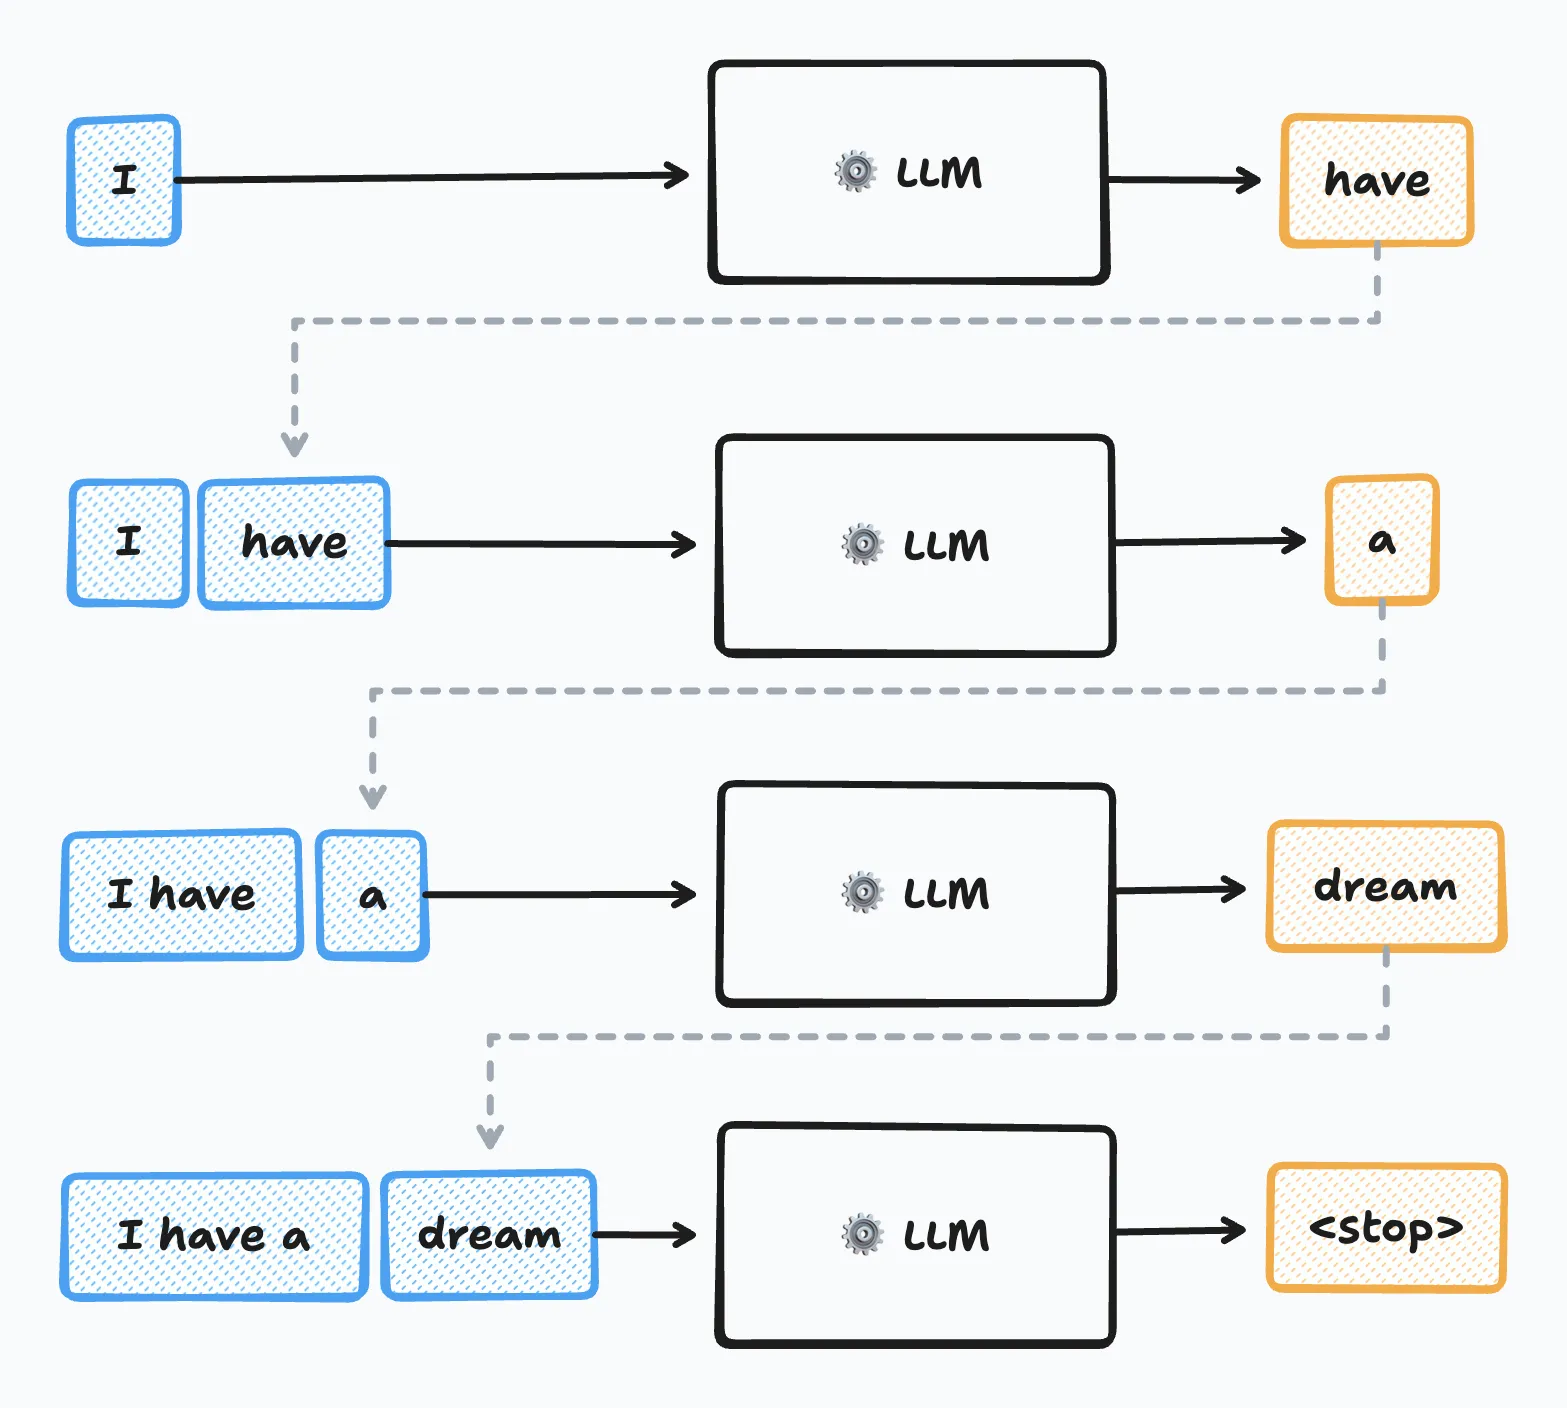

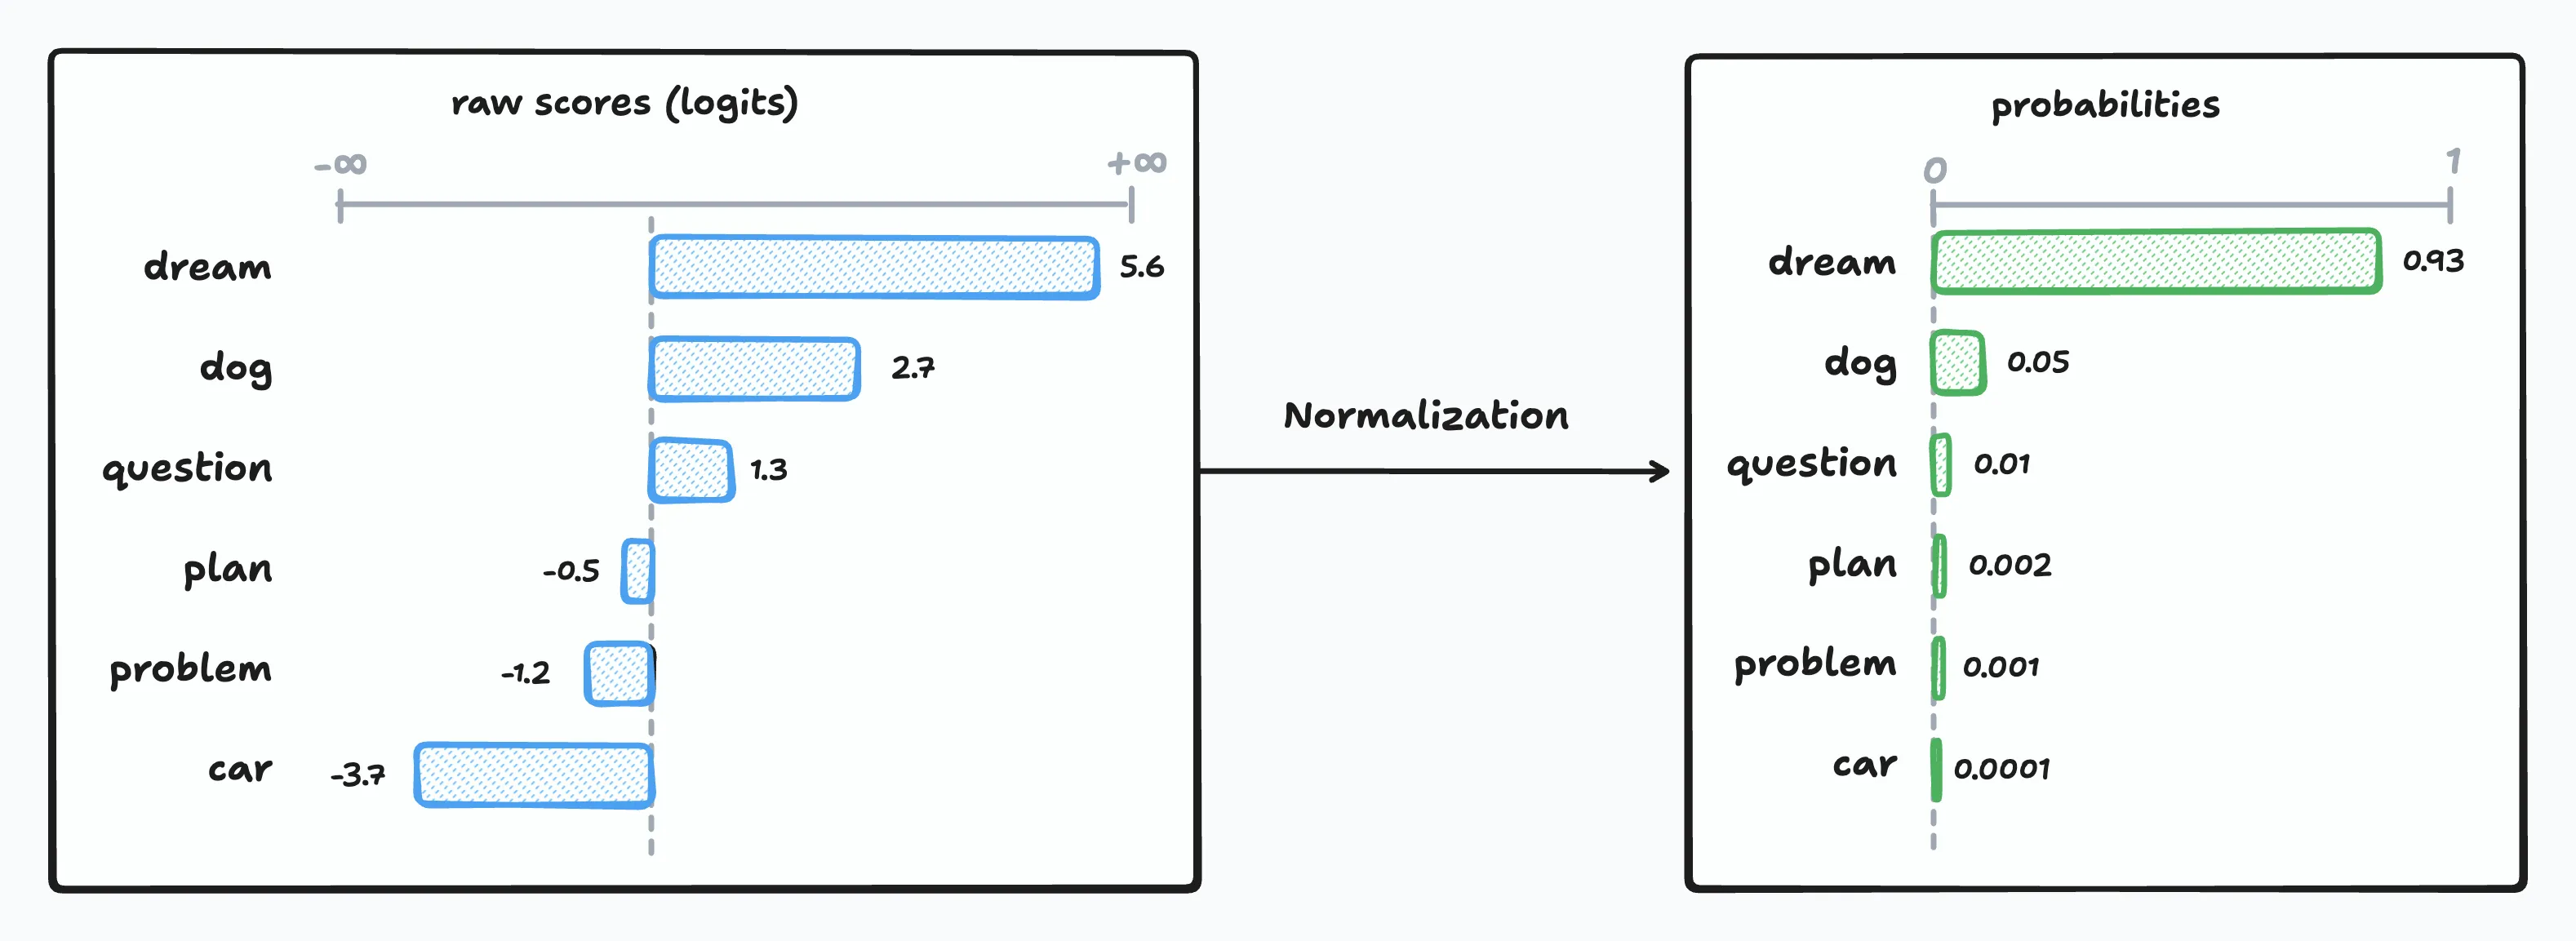

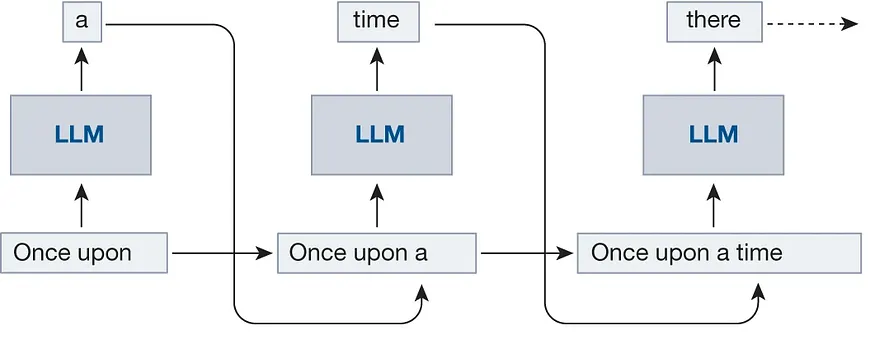

In [2]:
show_images(['Prediction.png', 'probs.png', 'LLM_regressive_generation.png'], width=760)


Images in this section are adapted from [pm.dartus.fr](https://pm.dartus.fr/).

## CrystaLLM

CrystaLLM treats crystal structure files as text. It learns the syntax and patterns of CIF-like structure descriptions, then generates new structure text autoregressively.


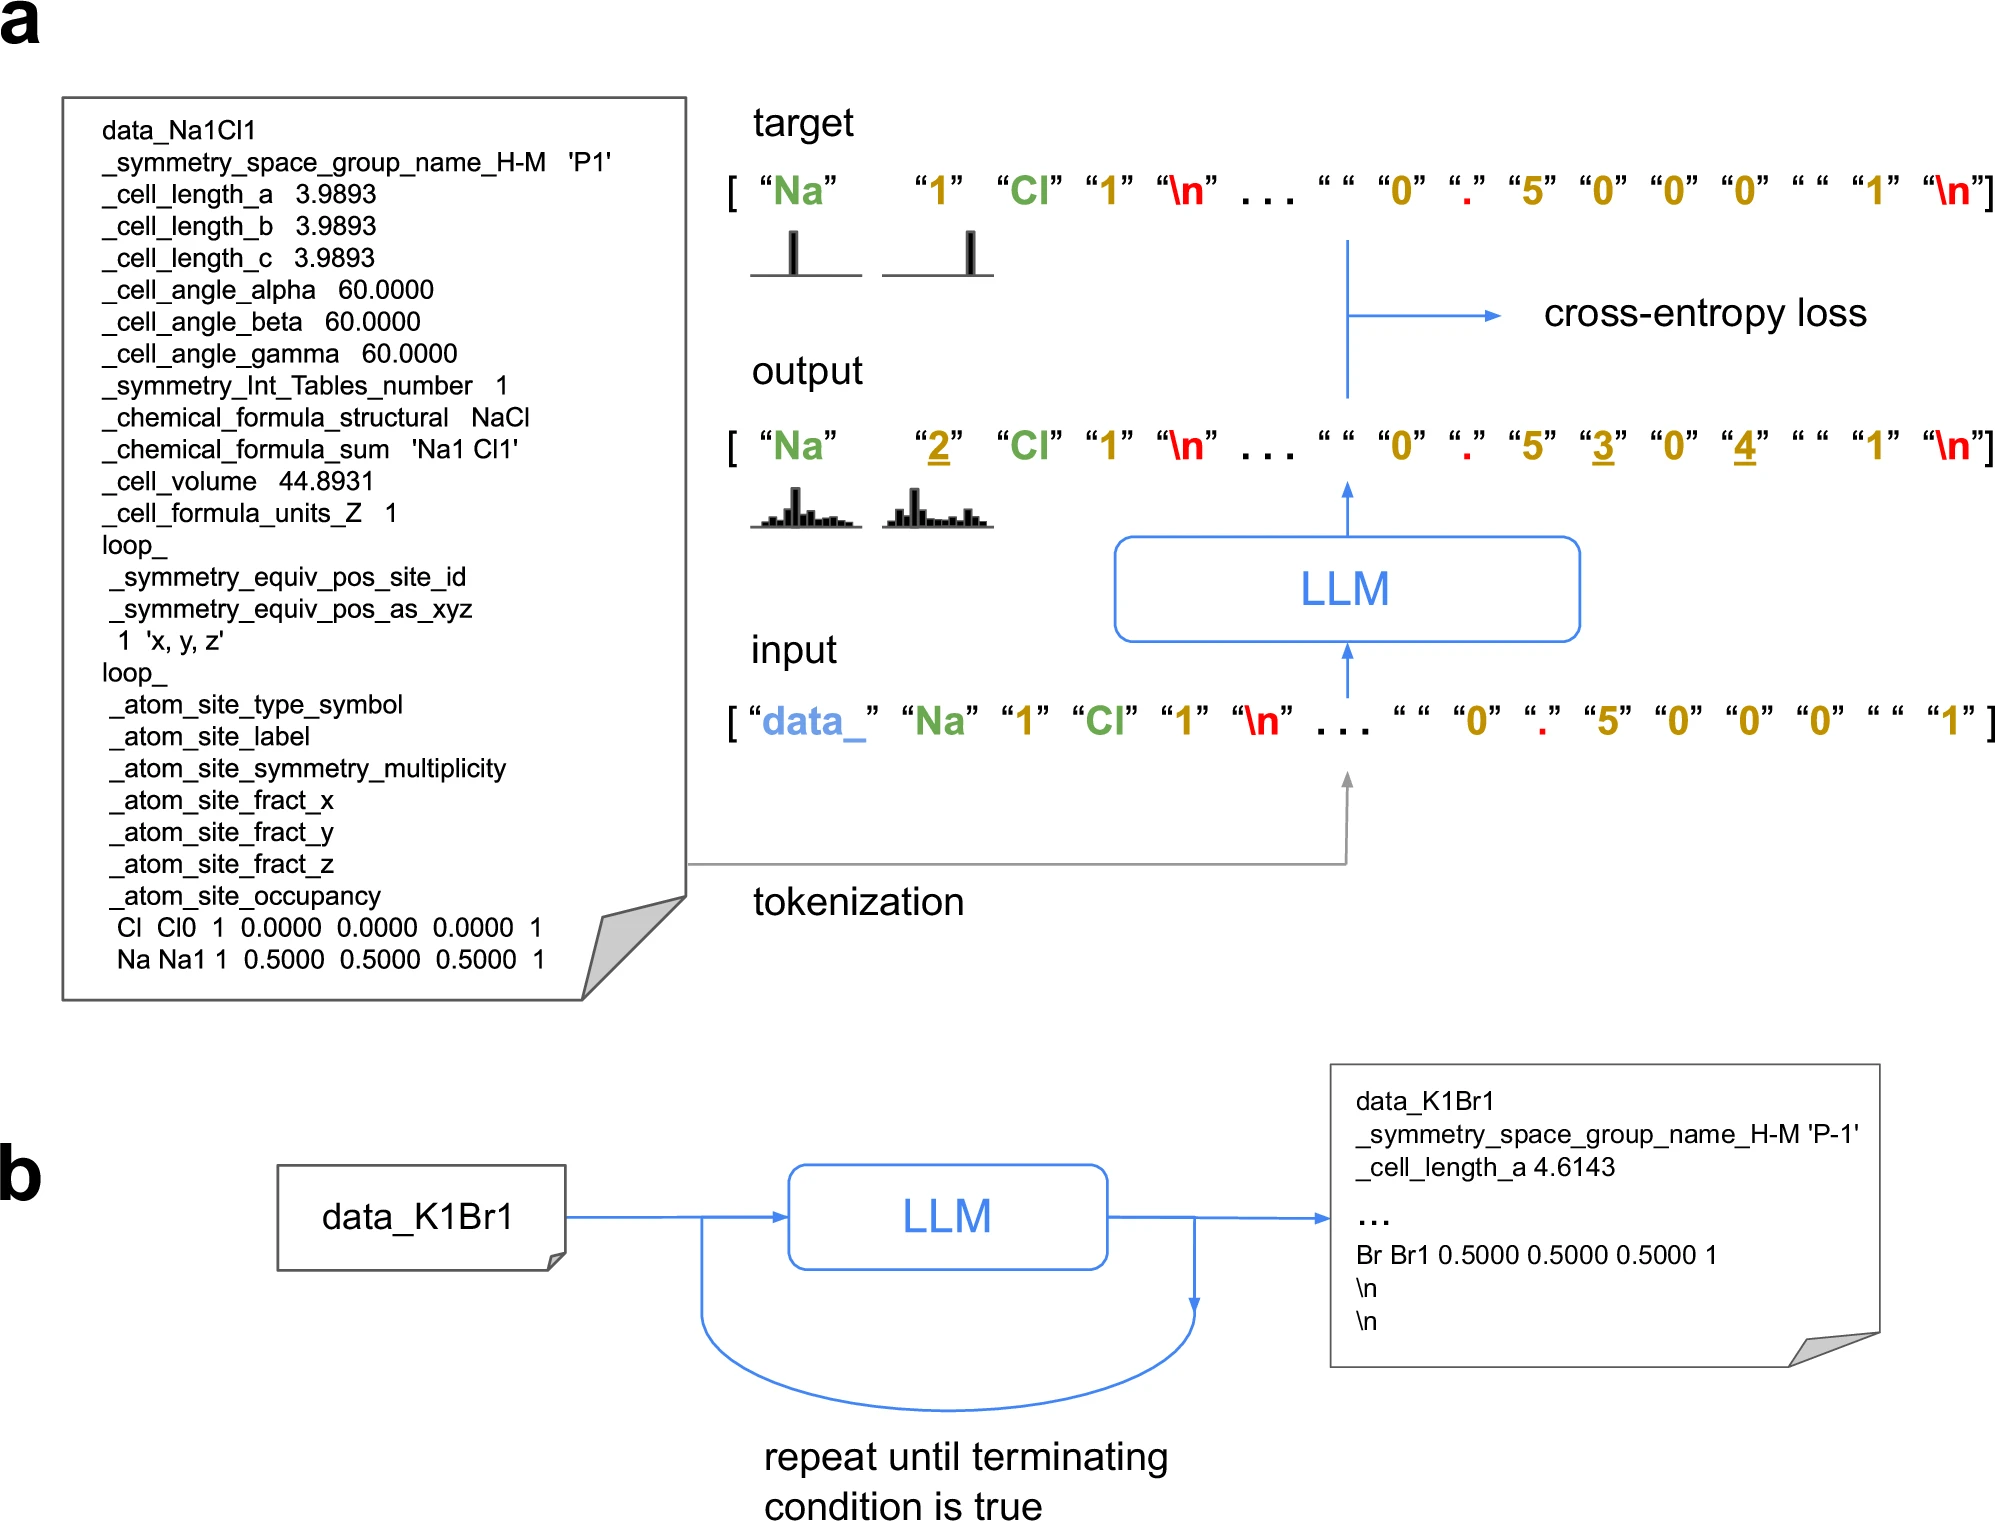

In [3]:
show_images(['LLM.png'], width=800)


## Plausibility Checks for Generated Structures

Generated CIFs should be checked before being interpreted as materials candidates:

1. **CIF syntax and symmetry consistency**: the file should parse correctly, and declared symmetry should match the positions.
2. **Bond lengths and site distances**: interatomic distances should be physically reasonable.
3. **Multiplicity and occupancy**: atom counts and occupancies should match the intended composition.
4. **Lattice and space-group realism**: lattice parameters and symmetries should resemble realistic crystal datasets.

## Monte Carlo Tree Search

MCTS can help guide generation by exploring multiple possible continuations and favouring text that produces more plausible structures.


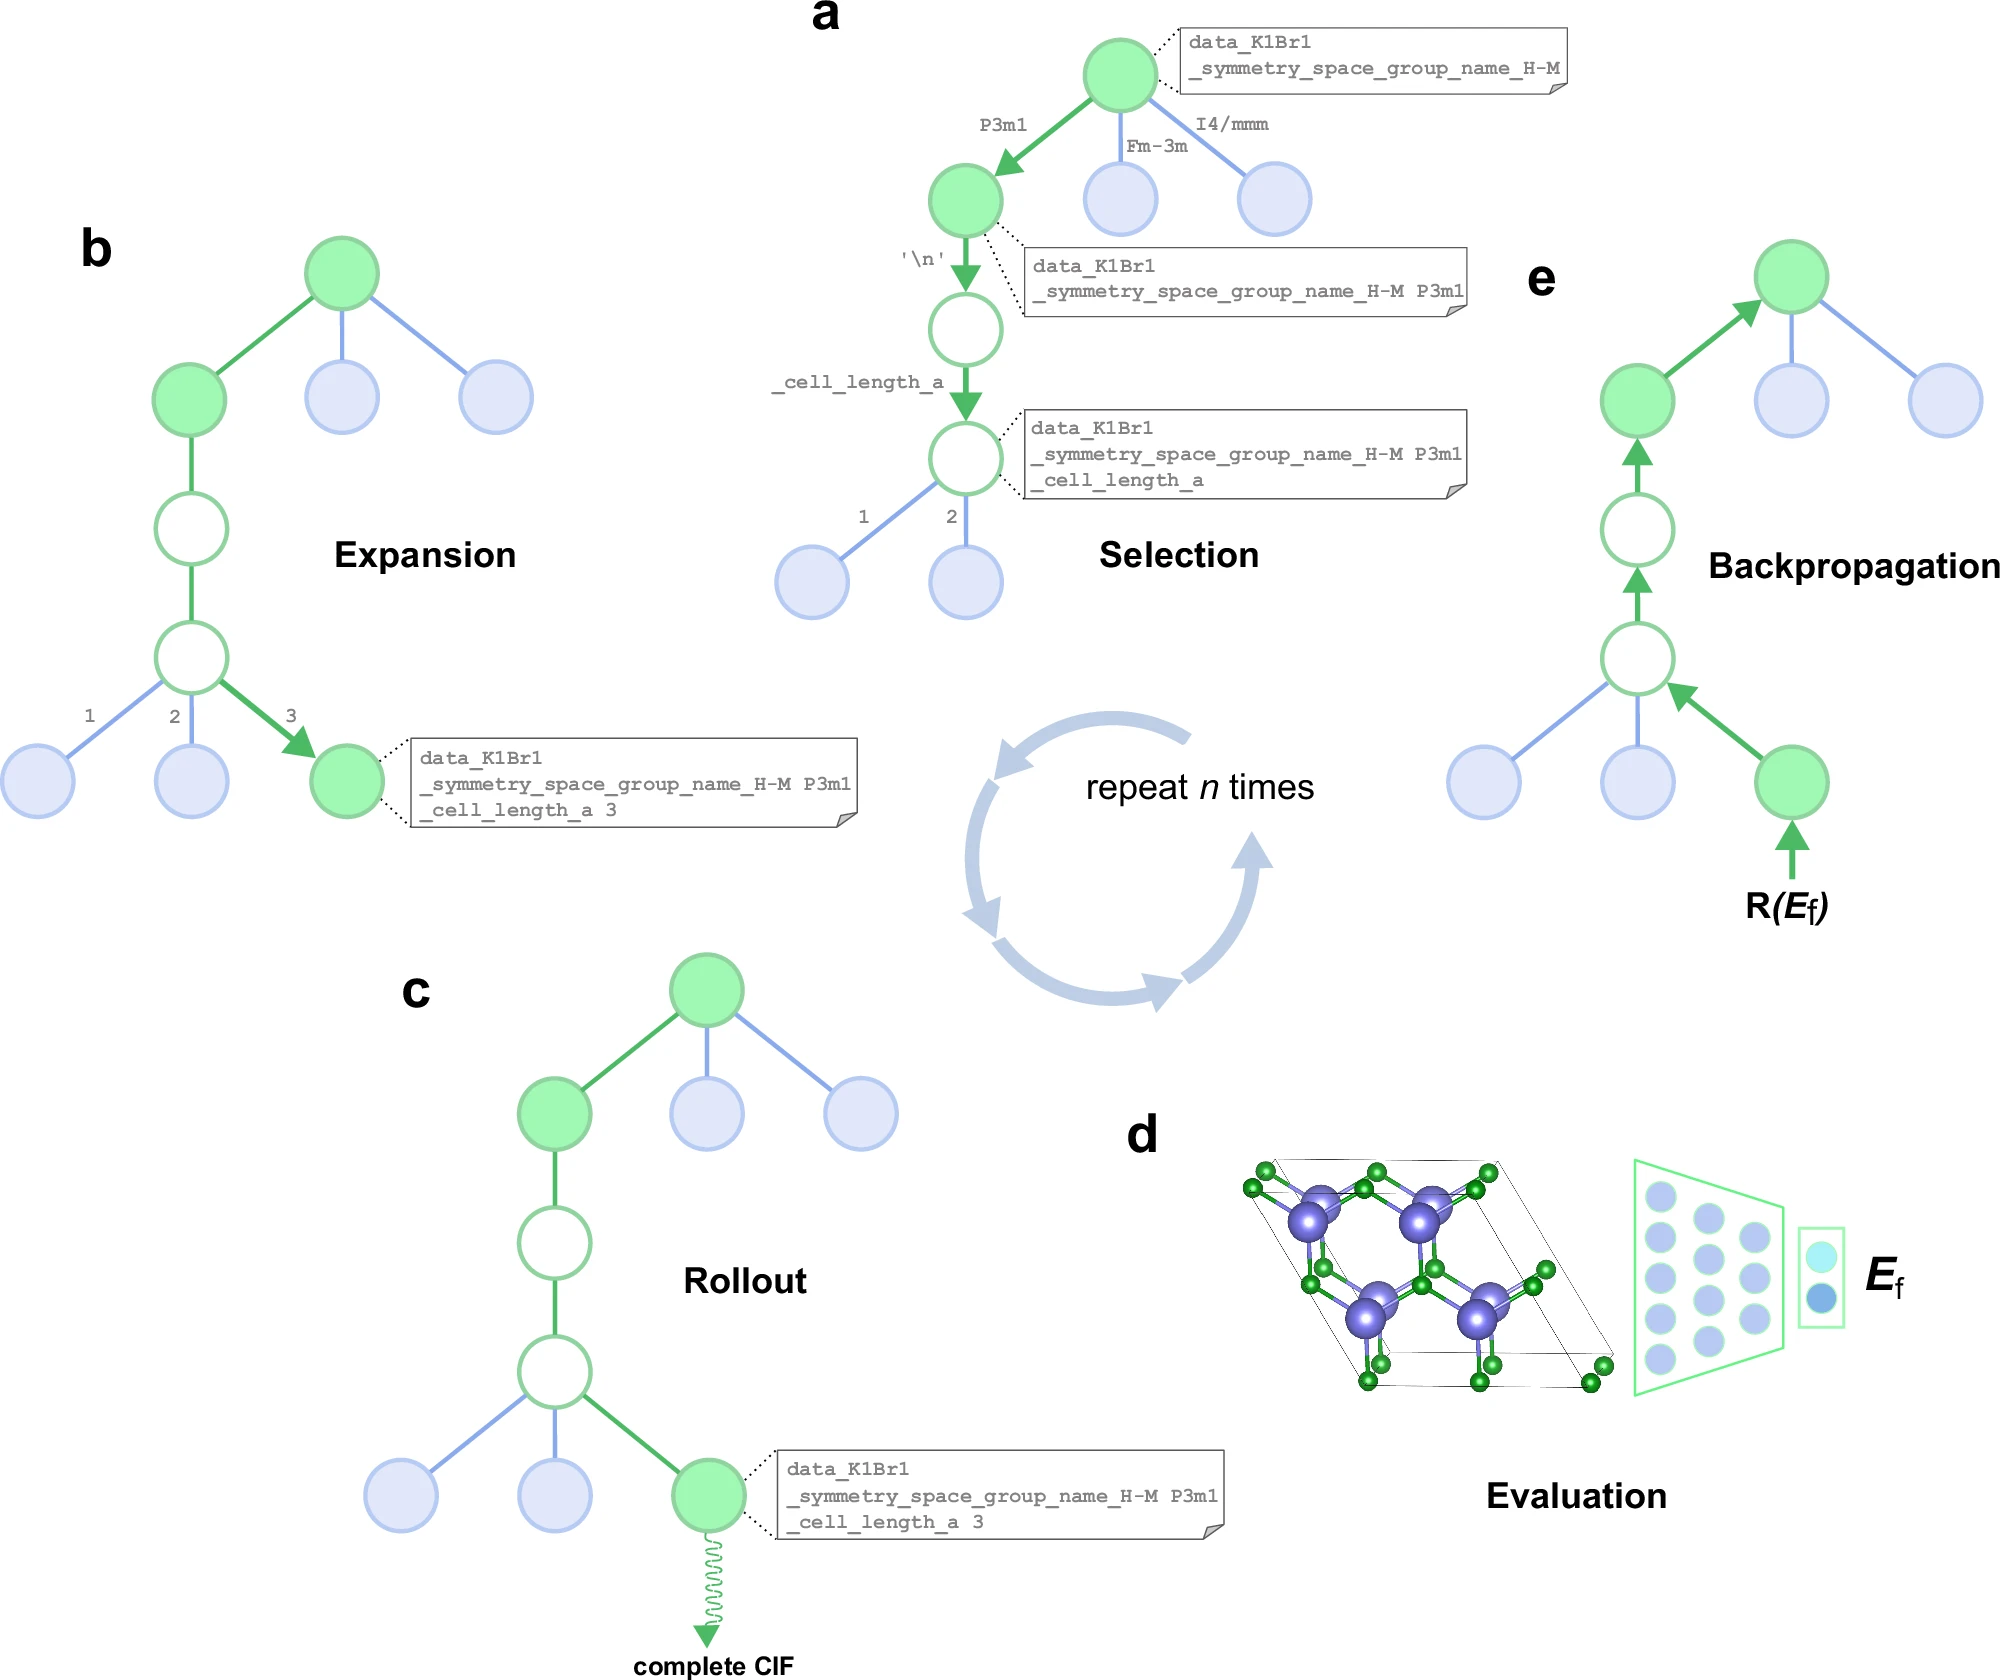

In [4]:
show_images(['MCTS.png'], width=800)


Image adapted from the paper: [Language models for crystal generation](https://www.nature.com/articles/s41467-024-54639-7).


## 1. Set Up CrystaLLM in Colab

This clones the official repository, installs CrystaLLM, and installs lightweight visualization tools.


In [5]:
repo = Path("/content/CrystaLLM")
if not repo.exists():
    subprocess.run(["git", "clone", "https://github.com/lantunes/CrystaLLM.git", str(repo)], check=True)
os.chdir(repo)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".", "pymatgen", "ase", "py3Dmol"], check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '-e', '.', 'pymatgen', 'ase', 'py3Dmol'], returncode=0)

## 2. Obtain the Pretrained Model

We download and unpack the small pretrained model, which is suitable for a quick Colab demonstration.


In [7]:
if not Path("crystallm_v1_small").exists():
    subprocess.run(["python", "bin/download.py", "crystallm_v1_small.tar.gz"], check=True)
    subprocess.run(["tar", "-xzf", "crystallm_v1_small.tar.gz"], check=True)


## 3. Generate a Prompt

CrystaLLM needs a starting text prompt. Here we use a formula. You can change `FORMULA` to another composition.


In [8]:
FORMULA = "LiMnO2"
create_prompt(FORMULA, "my_prompt.txt")
print(Path("my_prompt.txt").read_text())


data_Li1Mn1O2



Optional space-group prompt:

```python
create_prompt("Na2Cl2", "my_sg_prompt.txt", spacegroup="P4/nmm")
```


## 4. Run CrystaLLM

This samples three CIF files from the pretrained model and saves them as `sample_1.cif`, `sample_2.cif`, and `sample_3.cif`.


In [10]:
sample_py = Path("bin/sample.py")
sample_py.write_text(sample_py.read_text().replace("torch.load(ckpt_path, map_location=C.device)", "torch.load(ckpt_path, map_location=C.device, weights_only=False)"))
sample_args = ["python", "bin/sample.py", "out_dir=crystallm_v1_small/", "start=FILE:my_prompt.txt"]
sample_args += ["num_samples=3", "top_k=10", "max_new_tokens=3000", "device=cuda", "dtype=float32", "target=file", "seed=42"]
result = subprocess.run(sample_args, text=True, capture_output=True)
print(result.stdout); print(result.stderr)
assert result.returncode == 0, "CrystaLLM sampling failed. Read the printed error above."


Using configuration:
out_dir: crystallm_v1_small/
start: FILE:my_prompt.txt
num_samples: 3
max_new_tokens: 3000
temperature: 0.8
top_k: 10
seed: 42
device: cuda
dtype: float32
compile: false
target: file

number of parameters: 25.36M
writing generated content to sample_1.cif ...
writing generated content to sample_2.cif ...
writing generated content to sample_3.cif ...




## 5. Visualise a Generated Structure

Change `sample_1.cif` to `sample_2.cif` or `sample_3.cif` to inspect another generated structure.


In [11]:
show_cif("sample_1.cif")


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 6. Save Structures as CIF Files

The generated files are already CIF files. This cell lists them and makes them easy to download from Colab.


In [12]:
generated_cifs = sorted(Path(".").glob("sample_*.cif"))
print("Generated CIF files:", [p.name for p in generated_cifs])


Generated CIF files: ['sample_1.cif', 'sample_2.cif', 'sample_3.cif']


## 7. Download the CIF Files

Run this in Colab to download the generated structures.


In [13]:
from google.colab import files
for cif in generated_cifs:
    files.download(str(cif))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>